In [36]:
import numpy as np
import pandas as pd
import scipy.stats as stats #QQPLOT
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score
from sklearn.model_selection import cross_val_score
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.preprocessing import FunctionTransformer
from sklearn.compose import ColumnTransformer

In [37]:
df=pd.read_csv('/content/train (1).csv',usecols=['Age','Fare','Survived'])

In [38]:
df.head()

,Survived,Age,Fare
0,0,22.0,7.2500
1,1,38.0,71.2833
2,1,26.0,7.9250
3,1,35.0,53.1000
4,0,35.0,8.0500


In [39]:
df.isnull().sum()

,0
Survived,0
Age,177
Fare,0


In [40]:
df['Age'].fillna(df['Age'].mean(),inplace=True)

/tmp/ipykernel_843/694922604.py:1: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df['Age'].fillna(df['Age'].mean(),inplace=True)


In [41]:
df.isnull().sum()

,0
Survived,0
Age,0
Fare,0


In [42]:
X=df.iloc[:,1:3]
y=df.iloc[:,0]

In [43]:
X_train,X_test,y_train,y_test=train_test_split(X,y,test_size=0.2,random_state=42)

/tmp/ipykernel_843/1234970667.py:3: UserWarning: 

`distplot` is a deprecated function and will be removed in seaborn v0.14.0.

Please adapt your code to use either `displot` (a figure-level function with
similar flexibility) or `histplot` (an axes-level function for histograms).

For a guide to updating your code to use the new functions, please see
https://gist.github.com/mwaskom/de44147ed2974457ad6372750bbe5751

  sns.distplot(X_train['Age'])


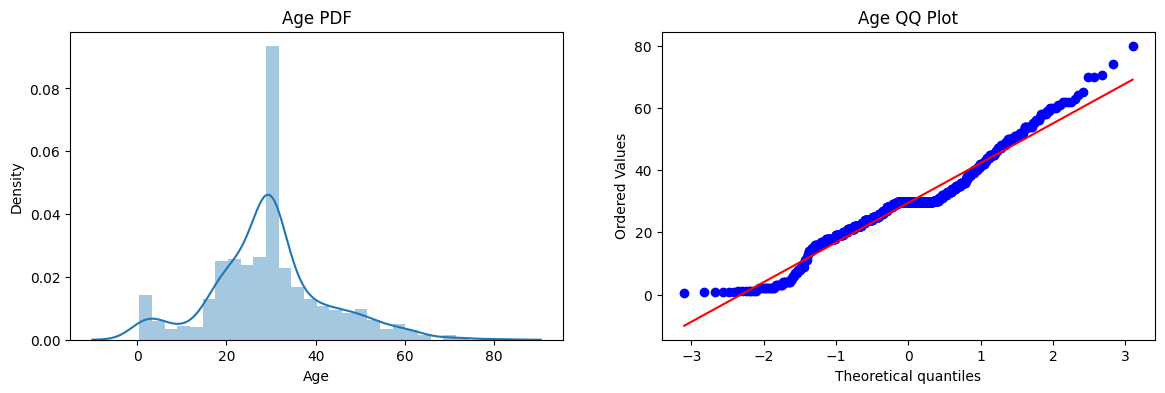

In [44]:
plt.figure(figsize=(14,4))
plt.subplot(121)
sns.distplot(X_train['Age'])
plt.title('Age PDF')
plt.subplot(122)
stats.probplot(X_train['Age'],dist="norm",plot=plt)
plt.title('Age QQ Plot')
plt.show()

In [45]:
clf=LogisticRegression()
clf1=DecisionTreeClassifier()

In [46]:
clf.fit(X_train,y_train)
clf1.fit(X_train,y_train)
y_pred=clf.predict(X_test)
y_pred1=clf1.predict(X_test)
print("Accuracy of LR",accuracy_score(y_test,y_pred))
print("Accuracy of DT",accuracy_score(y_test,y_pred1))

Accuracy of LR 0.6480446927374302
Accuracy of DT 0.6424581005586593


In [47]:
#NOW WITH TRANSFORMER

In [48]:
trf=FunctionTransformer(func=np.log1p)

In [49]:
X_train_transformed=trf.fit_transform(X_train)
X_test_transformed=trf.transform(X_test)

In [50]:
clf=LogisticRegression()
clf1=DecisionTreeClassifier()
clf.fit(X_train_transformed,y_train)
clf1.fit(X_train_transformed,y_train)
y_pred=clf.predict(X_test_transformed)
y_pred1=clf1.predict(X_test_transformed)
print("Accuracy of LR",accuracy_score(y_test,y_pred))
print("Accuracy of DT",accuracy_score(y_test,y_pred1))

Accuracy of LR 0.6815642458100558
Accuracy of DT 0.659217877094972


In [51]:
X_transformed=trf.fit_transform(X)
clf=LogisticRegression()
clf1=DecisionTreeClassifier()
print("LR",np.mean(cross_val_score(clf,X_transformed,y,cv=10,scoring='accuracy')))
print("DT",np.mean(cross_val_score(clf1,X_transformed,y,cv=10,scoring='accuracy')))

LR 0.678027465667915
DT 0.6577528089887641


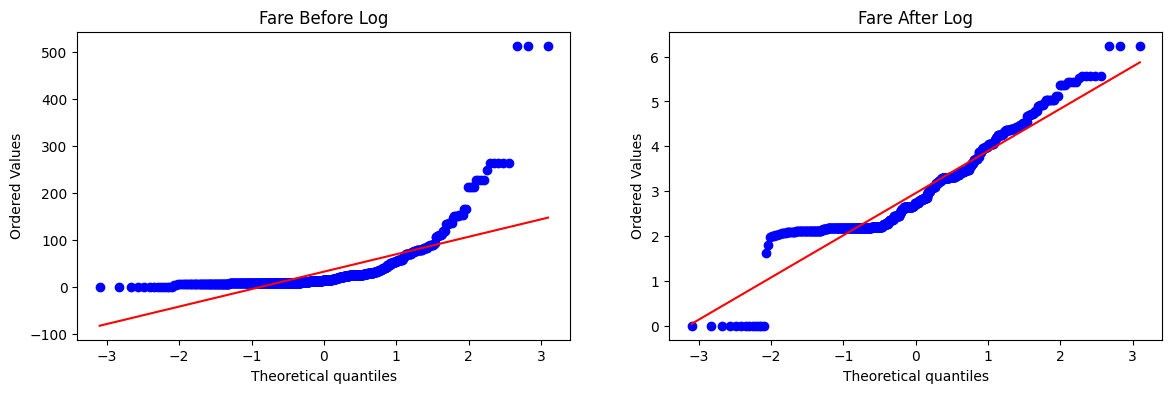

In [52]:
plt.figure(figsize=(14,4))
plt.subplot(121)
stats.probplot(X_train['Fare'],dist="norm",plot=plt)
plt.title('Fare Before Log')
plt.subplot(122)
stats.probplot(np.log1p(X_train['Fare']),dist="norm",plot=plt)
plt.title('Fare After Log')
plt.show()

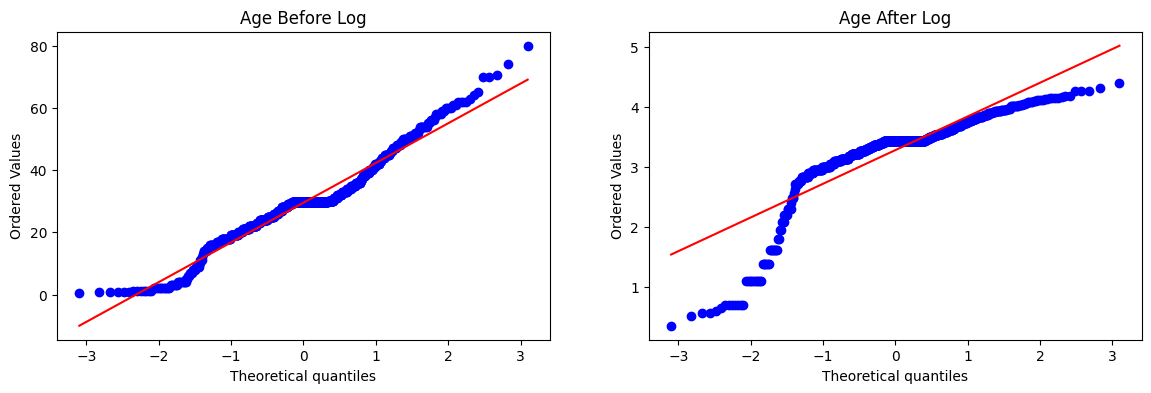

In [53]:
plt.figure(figsize=(14,4))
plt.subplot(121)
stats.probplot(X_train['Age'],dist="norm",plot=plt)
plt.title('Age Before Log')
plt.subplot(122)
stats.probplot(np.log1p(X_train['Age']),dist="norm",plot=plt)
plt.title('Age After Log')
plt.show()

In [54]:
trf2=ColumnTransformer([
    ('log',FunctionTransformer(np.log1p),['Fare'])
],remainder='passthrough')
X_train_transformed2=trf2.fit_transform(X_train)
X_test_transformed2=trf2.transform(X_test)

In [55]:
clf.fit(X_train_transformed2,y_train)
clf1.fit(X_train_transformed2,y_train)
y_pred=clf.predict(X_test_transformed2)
y_pred1=clf1.predict(X_test_transformed2)
print("Accuracy of LR",accuracy_score(y_test,y_pred))
print("Accuracy of DT",accuracy_score(y_test,y_pred1))

Accuracy of LR 0.6703910614525139
Accuracy of DT 0.6815642458100558


In [59]:
def apply_transform(transform):
  X=df.iloc[:,1:3]
  y=df.iloc[:,0]
  trf=ColumnTransformer([
    ('log',FunctionTransformer(transform),['Fare'])
  ],remainder='passthrough')
  X_trans=trf.fit_transform(X)
  clf=LogisticRegression()
  print("Accuracy",np.mean(cross_val_score(clf,X_trans,y,cv=10,scoring='accuracy')))
  plt.figure(figsize=(14,4))
  plt.subplot(121)
  stats.probplot(X['Fare'],dist="norm",plot=plt)
  plt.title('Fare Before Log')
  plt.subplot(122)
  stats.probplot(X_trans[:,0],dist="norm",plot=plt)
  plt.title('Fare After Log')
  plt.show()

Accuracy 0.61729088639201


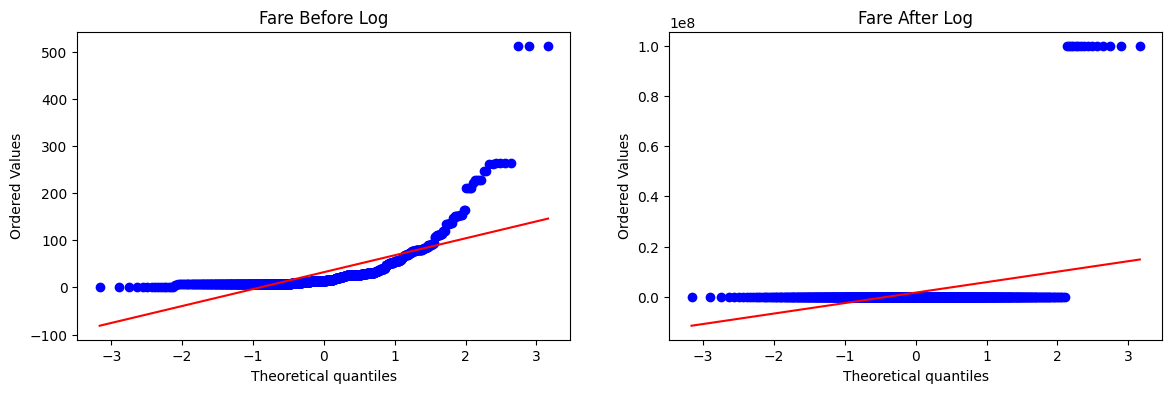

In [64]:
apply_transform(lambda x: 1/(x+0.00000001))